# LUNES 

<b>mercados | El camino importa: construye drawdown </b>

Genera una cartera ficticia 

y construye:

$$ Peak_t=\max_{s\leq t}W_s $$

y

$$ DD_t=\frac{W_t}{Peak_t}-1. $$

Calcula solamente:

- Annualized return
- Annualized volatility
- Sharpe
- Maximum drawdown
- Longest drawdown duration

Después crea:

> `r_shuffled = np.random.permutation(r)`

y repite exactamente las mismas métricas.

No cambiaste la distribución empírica de retornos: tienes exactamente los mismos 500 valores.

Responde entonces:

¿qué métricas permanecen prácticamente idénticas y cuál puede cambiar radicalmente?

- <b> RESPUESTA </b>
> Prácticamente idénticas: annualized return, annualized volatility y Sharpe. Usan los mismos 500 retornos; solo cambió su orden.
>
>Pueden cambiar radicalmente: maximum drawdown y longest drawdown duration, porque dependen de la secuencia con la que ocurren ganancias y pérdidas.

Explica por qué esto demuestra que:

$$ \boxed{\text{distribution of returns}} $$

y

$$ \boxed{\text{path of returns}} $$

no contienen exactamente la misma información.

- <b> RESPUESTA </b>
> distribución de retornos describe qué rendimientos ocurrieron y con qué dispersión, pero ignora el orden en que ocurrieron. El path incorpora la secuencia temporal: cuándo llegaron las pérdidas, cuánto se acumuló antes de recuperarse y cuánto tiempo permaneció el capital bajo su máximo previo.
Por ello, dos carteras pueden tener el mismo retorno final, volatilidad y Sharpe, pero experimentar drawdowns máximos y duraciones de recuperación muy diferentes. En la práctica no son equivalentes: un inversor o un Portfolio Engine debe poder sobrevivir el camino, no sólo alcanzar el mismo resultado final.

Pregunta de desk: ¿por qué un risk report que sólo contiene mean, volatility y Sharpe puede ocultar algo económicamente importante?

- <b> RESPUESTA </b>
> Porque mean, volatility y Sharpe resumen la distribución de retornos, pero no muestran cómo se recorrió el resultado. Ocultan la profundidad del máximo drawdown, cuánto tiempo permanece el capital bajo su máximo previo y la velocidad de recuperación.
Económicamente importa la riqueza acumulada a través del tiempo: un mismo Sharpe puede corresponder a una estrategia que soporta una caída breve del \(-10\%\), o a otra con un drawdown de \(-45\%\) durante años. La segunda puede obligar a reducir posiciones, incumplir límites de riesgo, perder capital de clientes o abandonar la estrategia antes de su eventual recuperación.

In [12]:
import numpy as np
import pandas as pd

np.random.seed(21)

r = np.random.normal(loc=0.0004,scale=0.01,size=500)
r_shuffled = np.random.permutation(r)
def metricas_cartera(r):
    wealth = (1 + pd.Series(r)).cumprod()
    # calculando metricas : peak y maxDD 
    peak = wealth.cummax()
    DD = (wealth / peak) -1
    maximum_drawdown = DD.min()
    underwater = wealth < peak
    T = len(r)
    annual_return = wealth.iloc[-1] ** (252/ T) - 1
    annual_vol = pd.Series(r).std() * np.sqrt(252)
    returns = pd.Series(r)
    sharpe = (returns.mean() / returns.std()) * np.sqrt(252)
    # Identifica bloques consecutivos True / False
    bloques = underwater.ne(underwater.shift()).cumsum()
    # Cuenta solo los días de los bloques bajo agua
    longest_dd_duration = (underwater[underwater].groupby(bloques[underwater]).size().max())
    return {
        "Annualized return": annual_return,
        "Annualized volatility": annual_vol,
        "Sharpe": sharpe,
        "Maximum drawdown": maximum_drawdown,
        "Longest drawdown duration": longest_dd_duration,
    }

resultados = pd.DataFrame(
    [metricas_cartera(r), metricas_cartera(r_shuffled)],
    index=["Original", "Shuffled"]
)

resultados



,Annualized return,Annualized volatility,Sharpe,Maximum drawdown,Longest drawdown duration
Original,0.16312,0.158252,1.034023,-0.143677,228
Shuffled,0.16312,0.158252,1.034023,-0.144354,198


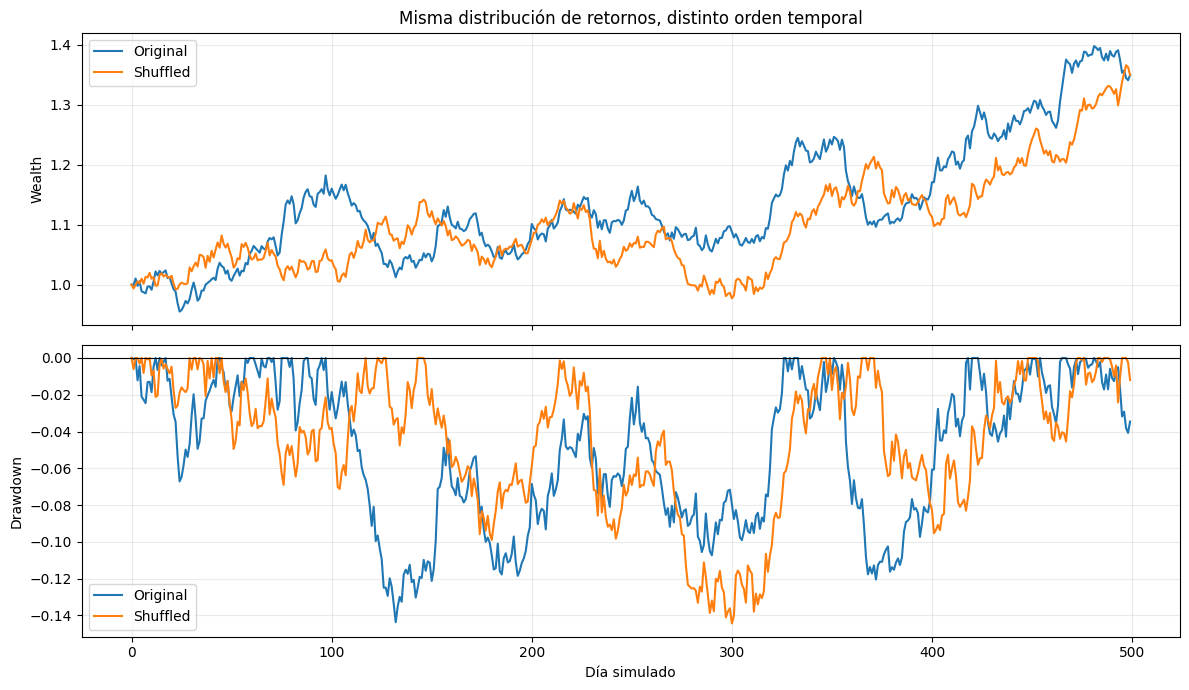

In [13]:
import matplotlib.pyplot as plt

def wealth_y_drawdown(r):
    wealth = (1 + pd.Series(r)).cumprod()
    peak = wealth.cummax()
    drawdown = wealth / peak - 1
    return wealth, drawdown

wealth_original, dd_original = wealth_y_drawdown(r)
wealth_shuffled, dd_shuffled = wealth_y_drawdown(r_shuffled)

fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

# Curvas de riqueza
axes[0].plot(wealth_original, label="Original", linewidth=1.5)
axes[0].plot(wealth_shuffled, label="Shuffled", linewidth=1.5)
axes[0].set_title("Misma distribución de retornos, distinto orden temporal")
axes[0].set_ylabel("Wealth")
axes[0].legend()
axes[0].grid(alpha=0.25)

# Drawdowns
axes[1].plot(dd_original, label="Original", linewidth=1.5)
axes[1].plot(dd_shuffled, label="Shuffled", linewidth=1.5)
axes[1].axhline(0, color="black", linewidth=0.8)
axes[1].set_xlabel("Día simulado")
axes[1].set_ylabel("Drawdown")
axes[1].legend()
axes[1].grid(alpha=0.25)

plt.tight_layout()
plt.show()

<b> Research + Quant Desk | ¿Alpha murió o sólo está en drawdown? </b>

Una estrategia live presenta:

| Métrica   | Backtest OOS | Live últimos 3 meses |
| --------- | -----------: | -------------------: |
| Sharpe    |         1.35 |                -0.42 |
| Hit rate  |        53.8% |                48.9% |
| Avg trade |     +4.2 bps |             -1.1 bps |
| Max DD    |        -8.1% |                -7.4% |
| Turnover  |         1.7x |                 1.8x |
| Costs     |      1.3 bps |              1.4 bps |


Un trader dice:

“Está en drawdown. Hay que apagarla.”

Otro dice:

“El drawdown sigue dentro del histórico. No hacemos nada.”

No aceptes ninguna conclusión todavía.

Formula tres explicaciones rivales:

$$ H_1:\text{variación normal de una estrategia todavía válida} $$ $$ H_2:\text{cambio del régimen económico que sustentaba el alpha} $$ $$ H_3:\text{degradación de implementación/ejecución}. $$

Para cada una escribe una observación que esperarías encontrar si fuera cierta.

- <b> RESPUESTA  </b>

| Hipótesis | Observación que esperarías si fuera cierta |
|---|---|
| \(H_1\): variación normal | El resultado live de 3 meses cae dentro de un intervalo esperable según la distribución OOS de retornos/Sharpes de ventanas de igual longitud. El alpha bruto, costes y exposiciones a factores se mantienen aproximadamente estables. |
| \(H_2\): cambio de régimen | La señal pierde eficacia específicamente en un entorno identificable: por ejemplo, volatilidad alta, tendencia fuerte, spreads amplios o tipos al alza. Verías que el alpha o hit rate condicional a ese régimen cae, mientras que en el régimen histórico relevante aún funciona. |
| \(H_3\): degradación de ejecución | El alpha teórico o *paper PnL* sigue siendo positivo, pero el PnL realizado se deteriora: mayor slippage, peores fills, mayor latencia, rechazos, impacto o desviación entre precio decidido y precio ejecutado. |

Después diseña un único experimento diagnóstico para mañana que permita separar al menos dos de estas explicaciones. No puedes modificar el modelo ni buscar nuevas features.

Finalmente decide provisionalmente:

$$ \boxed{\text{KEEP RUNNING}} \qquad \boxed{\text{DE-RISK}} \qquad \boxed{\text{HALT}}. $$

Tu decisión debe basarse en la evidencia disponible, no únicamente en que el P&L sea negativo.

- <b>RESPUESTA </b>
Un experimento diagnóstico útil es correr mañana el modelo congelado en paralelo con dos libros:
1. Paper portfolio: mismas señales, mismas horas y mismas reglas, pero operaciones simuladas al precio ejecutable definido antes de enviar la orden.
2. Live portfolio: las órdenes reales, quizá con tamaño reducido, registrando precio de decisión, bid/ask, precio de llegada, fills, slippage, latencia y rechazos.
No cambias modelo, features ni regla de trading. Sólo observas la brecha entre la decisión y la ejecución

| Resultado | Interpretación |
|---|---|
| Paper PnL razonable, pero live PnL malo | Evidencia a favor de \(H_3\): implementación o ejecución. |
| Paper y live PnL malos, con brecha pequeña | \(H_3\) pierde fuerza; queda \(H_1\) o \(H_2\). |
| Paper/live malos sólo bajo un régimen identificable | Evidencia a favor de \(H_2\). |
| Paper/live malos, pero dentro de bandas estadísticas esperadas de ventanas OOS de 3 meses | Evidencia a favor de \(H_1\). |

No HALT: el máximo drawdown live (\(-7.4\%\)) todavía está dentro del histórico OOS (\(-8.1\%\)); no hay evidencia suficiente de que la estrategia haya muerto.
No KEEP RUNNING al riesgo normal: Sharpe, hit rate y promedio por trade se deterioraron de forma material. Reducir tamaño preserva capital mientras conservas observaciones live limpias para diagnosticar si el problema es ejecución, régimen o variación normal.

DECISION PROVISIONAL RAZONABLE ES : 
<b>DE - RISK  </b>:reducir el riesgo de la estrategia temporalmente, sin apagarla por completo. 

# MARTES

<b> Risk | Un activo puede volverse peligroso sin cambiar su volatilidad </b>

Usa los mismos pesos y volatilidades implícitas.

Tienes tres estrategias con pesos

$$ w= \begin{pmatrix} 0.50\\ 0.30\\ 0.20 \end{pmatrix} $$

y matriz de covarianza diaria

$$ \Sigma = \begin{pmatrix}
0.000100 & 0.000036 & -0.000012 \\
0.000036 & 0.000144 & 0.000000 \\
-0.000012 & 0.000000 & 0.000064
\end{pmatrix} $$ 

$ \sigma_P = \sqrt{w^\top \Sigma w} $



Construye dos matrices de correlación:

>corr_normal = np.array([
    [1.0,  0.30, -0.15],
    [0.30, 1.0,   0.00],
    [-0.15,0.00,  1.0]
])

>corr_stress = np.array([
    [1.0, 0.80, 0.60],
    [0.80,1.0,  0.70],
    [0.60,0.70, 1.0]
])


Mantén exactamente:

`vol = np.array([0.01, 0.012, 0.008])`

y construye:

$$ \Sigma=D\,Corr\,D, \qquad D=\operatorname{diag}(\sigma). $$

Para cada régimen calcula únicamente:

- portfolio_vol
- %RC_A
- %RC_B
- %RC_C

Entrega

|               | Normal | Stress |
| ------------- | -----: | -----: |
| Portfolio vol |        |        |
| RC A          |        |        |
| RC B          |        |        |
| RC C          |        |        |

No cambies pesos ni volatilidades.

Después responde:

¿Qué cambió económicamente si cada estrategia conserva exactamente su standalone volatility?

- <b> </b>

> Aunque cada estrategia conserva su misma volatilidad individual, aumentaron las correlaciones entre ellas. Por tanto, las posiciones se mueven más en la misma dirección y se pierde diversificación. Como consecuencia, sube la volatilidad total del portafolio y cambian las contribuciones de riesgo de A, B y C.
Económicamente, el riesgo no pertenece de forma aislada a un activo: depende de su peso y de cómo co-mueve con el resto del portafolio. En estrés, activos que parecían diversificadores pueden dejar de proteger simultáneamente.

Quiero que identifiques que el riesgo no pertenece aisladamente a una posición:

$$ \boxed{RC_i=RC_i(w,\Sigma)}. $$

Es decir, la misma estrategia puede aportar cantidades radicalmente distintas de riesgo dependiendo de qué más tienes en el portfolio y cómo se mueve conjuntamente con ello.

In [3]:
import numpy as np
import pandas as pd

w = np.array([0.50, 0.30, 0.20])

vol = np.array([0.01, 0.012, 0.008])
D = np.diag(vol)

corr_normal = np.array([
    [1.0,  0.30, -0.15],
    [0.30, 1.0,   0.00],
    [-0.15, 0.00, 1.0]
])

corr_stress = np.array([
    [1.0, 0.80, 0.60],
    [0.80, 1.0, 0.70],
    [0.60, 0.70, 1.0]
])

cov_normal = D @ corr_normal @ D
cov_stress = D @ corr_stress @ D

def risk_metrics(w, cov):
    portfolio_vol = np.sqrt(w @ cov @ w)

    # RC_i = w_i * (Sigma w)_i / sigma_P
    rc = w * (cov @ w) / portfolio_vol
    pct_rc = rc / portfolio_vol * 100

    return portfolio_vol, pct_rc

vol_normal, rc_normal = risk_metrics(w, cov_normal)
vol_stress, rc_stress = risk_metrics(w, cov_stress)

resultados = pd.DataFrame(
    {
        "Normal": [vol_normal, *rc_normal],
        "Stress": [vol_stress, *rc_stress]
    },
    index=["Portfolio vol", "%RC_A", "%RC_B", "%RC_C"]
)

resultados


,Normal,Stress
Portfolio vol,0.006994,0.009327
%RC_A,59.689289,50.813943
%RC_B,37.530662,36.089396
%RC_C,2.780049,13.096661


<b> Quant Desk + Research | ¿Quién debe recibir el siguiente dólar? </b>

Tu desk tiene:

| Strategy | Expected Alpha | Standalone vol | Weight | %RC |
| -------- | -------------: | -------------: | -----: | --: |
| A        |         +9 bps |           1.0% |    40% | 58% |
| B        |         +6 bps |           0.8% |    35% | 31% |
| C        |         +4 bps |           0.7% |    25% | 11% |


Research descubre evidencia adicional favorable para A y actualiza:

$$ \hat\alpha_A:9\rightarrow11\text{ bps}. $$

Un sistema ingenuo concluye:

$$ \alpha_A\uparrow \Rightarrow w_A\uparrow. $$

No aceptes todavía esa decisión.

Diseña el flujo:

$$ \text{Alpha Engine} \rightarrow \boxed{?} \rightarrow \text{Portfolio Engine} \rightarrow \boxed{?} \rightarrow \text{Execution}. $$

- <b> Respuesta </b>
> - Alpha Engine: entrega $ \hat\alpha_A=11 $  bps, pero también incertidumbre, evidencia, vigencia y calidad de la estimación. 
>  - Alpha Governance: transforma o valida esa estimación antes de usarla. Por ejemplo, un alpha de 11 bps con enorme error estándar no debe tratarse igual que uno muy preciso.
> - Portfolio Engine: propone pesos objetivo considerando alpha ajustado, presupuesto de riesgo, covarianzas y concentración. Aquí se decide cuánto capital/riesgo asignar a A.
> - Pre-trade Risk Gate: no “inventa” la asignación ni busca alpha; verifica que la propuesta respete límites de concentración, riesgo, drawdown, liquidez y factibilidad de la operación. Puede aprobar, reducir o bloquear.
> - Execution: convierte la orden aprobada en ejecución real; optimiza cómo ejecutar, registra fills, slippage y puede cancelar si el mercado ya no permite operar de forma segura.



Los dos huecos deben representar las capas que necesitas para evitar que una señal fuerte se convierta automáticamente en concentración de riesgo.

Después tienes tres acciones posibles:

$$ \boxed{\text{INCREASE A}} \qquad \boxed{\text{KEEP A}} \qquad \boxed{\text{REBALANCE RISK}} $$

y sólo puedes solicitar tres datos adicionales antes de decidir. Escógelos entre:

- current covariance/dependence
- alpha uncertainty
- transaction costs
- historical maximum price
- ticker sector
- portfolio drawdown
- liquidity

- <b> Respuesta </b>

| Dato adicional | Por qué es indispensable |
|---|---|
| `alpha uncertainty` | El cambio de \(9\) a \(11\) bps sólo importa si es estadísticamente y económicamente creíble. Sin incertidumbre, no sabemos si esos 2 bps son señal o ruido. |
| `current covariance/dependence` | A ya aporta \(58\%\) del riesgo. Necesitamos saber si su dependencia con B y C ha aumentado, porque el riesgo marginal de aumentar A puede ser mucho mayor que su volatilidad standalone sugiere. |
| `transaction costs` | El aumento esperado de alpha es sólo \(2\) bps. Si rebalancear hacia A cuesta más que el beneficio esperado —o consume gran parte de él— aumentar A no es económicamente justificable. |

Justifica por qué elegiste exactamente esos tres.

Finalmente responde:

Si A tiene el mayor alpha esperado pero ya genera 58% del riesgo, ¿significa eso que A está “sobreponderada”?

La respuesta no puede ser simplemente sí/no. Distingue:

$$ \boxed{\text{capital concentration}} $$

de

$$ \boxed{\text{risk concentration}} $$

y de

$$ \boxed{\text{undesirable concentration}} $$


- <b> RESPUESTA </b>

> No necesariamente. Que A genere 58% del riesgo no implica automáticamente
> que tenga demasiado capital asignado ni que deba reducirse. Puede tener una ponderación de capital moderada, pero aportar mucho riesgo por su volatilidad, covarianza o dependencia con el resto de la cartera.
Debemos separar:
> - Capital concentration: proporción del capital en A, por ejemplo $ w_A=40\% $.
> - Risk concentration: proporción del riesgo total explicada por A, por ejemplo     $ RC_A=58\% $.
> - Undesirable concentration: ocurre sólo si alguna de esas concentraciones excede un límite o presupuesto definido por la política de cartera, considerando la calidad y diversificación del alpha, liquidez, covarianza y escenarios de estrés.
>
> Por tanto, A puede seguir teniendo el mayor alpha esperado, pero asignarle más capital podría aumentar una concentración de riesgo ya elevada. Antes de INCREASE A, el Portfolio Engine tendría que verificar si el alpha adicional compensa su contribución marginal de riesgo y los costes de rebalanceo.

# <b> MIERCOLES </b>

<B> Portfolio | Equal capital vs. equal risk </b>

Tres estrategias independientes tienen:

$$ \sigma= (5\%,10\%,20\%) $$

anualizadas.

Primero construye:

> `vol = np.array([0.05, 0.10, 0.20])`
>
>`w_equal = np.ones(3) / 3`

Asume inicialmente:

$$ Corr=I. $$

Calcula la volatilidad del portfolio y las \(\%RC_i\) usando los pesos iguales.

Después construye pesos inverse-vol:

$$ w_i\propto\frac{1}{\sigma_i}, \qquad \sum_iw_i=1. $$

Calcula nuevamente:

- portfolio_vol
- %RC_A
- %RC_B
- %RC_C

Entrega únicamente:

|               | Equal Capital | Inverse Vol |
| ------------- | ------------: | ----------: |
| \(w_A\)       |               |             |
| \(w_B\)       |               |             |
| \(w_C\)       |               |             |
| Portfolio vol |               |             |
| RC A          |               |             |
| RC B          |               |             |
| RC C          |               |             |

Ahora modifica sólo la correlación:

$$ Corr = \begin{pmatrix}
1 & 0.8 & 0 \\
0.8 & 1 & 0 \\
0 & 0 & 1
\end{pmatrix} $$

Mantén los pesos inverse-vol y vuelve a calcular las contribuciones.

Pregunta central:

¿Por qué inverse-vol produce equal risk contribution bajo ciertas condiciones, pero deja de garantizarlo cuando aparece dependencia?

Quiero que llegues a:

$$ \boxed{\frac1{\sigma_i}\text{ conoce marginales, pero ignora }\Sigma_{ij}.} $$

No implementes todavía un Risk Parity optimizer.

In [5]:
import pandas as pd 
import numpy as np 

vol = np.array([0.05, 0.10, 0.20])
D = np.diag(vol)
 
def risk_metrics(w, cov):
    portfolio_vol = np.sqrt(w @ cov @ w)
    # RC_i = w_i * (Sigma w)_i / sigma_P
    rc = w * (cov @ w) / portfolio_vol
    pct_rc = rc / portfolio_vol * 100
    return portfolio_vol, pct_rc

# correlacion = I ; Estrategias independientes 
corr = np.eye(3)
cov = D @ corr @ D 
# Equal capital: 1/3 para cada estrategia
w_equal = np.ones(3) / 3
vol_equal, rc_equal = risk_metrics(w_equal, cov)
# Inverse-vol: normalizar 1 / sigma para que los pesos sumen 1
w_inv_vol = 1 / vol
w_inv_vol = w_inv_vol / w_inv_vol.sum()
vol_inv, rc_inv = risk_metrics(w_inv_vol, cov)

tabla = pd.DataFrame(
    {
        "Equal Capital": [
            *w_equal,
            vol_equal,
            *rc_equal
        ],
        "Inverse Vol": [
            *w_inv_vol,
            vol_inv,
            *rc_inv
        ]
    },
    index=["w_A", "w_B", "w_C", "Portfolio vol", "RC A (%)", "RC B (%)", "RC C (%)"]
)

tabla 

,Equal Capital,Inverse Vol
w_A,0.333333,0.571429
w_B,0.333333,0.285714
w_C,0.333333,0.142857
Portfolio vol,0.076376,0.049487
RC A (%),4.761905,33.333333
RC B (%),19.047619,33.333333
RC C (%),76.190476,33.333333


In [17]:
# Pesos: se mantienen iguales entre escenarios
w_equal = np.ones(3) / 3

w_inv_vol = 1 / vol
w_inv_vol = w_inv_vol / w_inv_vol.sum()

# Escenario base: independencia
corr_base = np.eye(3)
cov_base = D @ corr_base @ D

# Escenario alterado: correlación A-B = 0.8
corr_ab = np.eye(3)
corr_ab[0, 1] = 0.8
corr_ab[1, 0] = 0.8
cov_ab = D @ corr_ab @ D

# Métricas de cada escenario
vol_equal_base, rc_equal_base = risk_metrics(w_equal, cov_base)
vol_inv_base, rc_inv_base = risk_metrics(w_inv_vol, cov_base)

vol_equal_ab, rc_equal_ab = risk_metrics(w_equal, cov_ab)
vol_inv_ab, rc_inv_ab = risk_metrics(w_inv_vol, cov_ab)

indices = ["w_A", "w_B", "w_C", "Portfolio vol", "RC A (%)", "RC B (%)", "RC C (%)"]

tabla_comparacion = pd.DataFrame({
    "Equal Capital — Corr = I":
        [*w_equal, vol_equal_base, *rc_equal_base],

    "Inverse Vol — Corr = I":
        [*w_inv_vol, vol_inv_base, *rc_inv_base],

    "Equal Capital — Corr AB = 0.8":
        [*w_equal, vol_equal_ab, *rc_equal_ab],

    "Inverse Vol — Corr AB = 0.8":
        [*w_inv_vol, vol_inv_ab, *rc_inv_ab],
}, index=indices)

tabla_comparacion

,Equal Capital — Corr = I,Inverse Vol — Corr = I,Equal Capital — Corr AB = 0.8,Inverse Vol — Corr AB = 0.8
w_A,0.333333,0.571429,0.333333,0.571429
w_B,0.333333,0.285714,0.333333,0.285714
w_C,0.333333,0.142857,0.333333,0.142857
Portfolio vol,0.076376,0.049487,0.081989,0.061279
RC A (%),4.761905,33.333333,10.743802,39.130435
RC B (%),19.047619,33.333333,23.140496,39.130435
RC C (%),76.190476,33.333333,66.115702,21.739130


<b> Mercados + Quant Desk | ¿Quién tiene permiso de reducir exposición? </b>

Tu desk tiene un portfolio cuya configuración objetivo es:

- vol_target       = 10%
- max_strategy_RC  = 35%

A las 10:00:

>forecast portfolio vol = 9.4%

>RC_A = 32%

>RC_B = 28%

>RC_C = 22%

>RC_D = 18%

A las 11:30 ocurre un shock de mercado:

> forecast portfolio vol = 15.2%

> RC_A = 51%

> RC_B = 20%

> RC_C = 16%

> RC_D = 13%

Los forecasts de Alpha no han cambiado.

Tienes cuatro acciones conceptuales:

$$ A:\quad w\rightarrow kw $$

escalar proporcionalmente todo el portfolio.

$$ B:\quad w_A\downarrow $$

reducir específicamente A.

$$ C:\quad\text{hacer A y después B} $$ $$ D:\quad\text{no hacer nada}. $$

No elijas inmediatamente.

Primero identifica qué problema diagnostica cada métrica:

$$ 15.2\%>10\% $$

y

$$ RC_A=51\%>35\%. $$

Después determina qué acción corrige risk level, cuál corrige risk composition, y cuál podría ser necesaria si ambas restricciones son vinculantes.

Ahora diseña este flujo para tu Quant Desk:

$$ \text{Alpha} \rightarrow \text{Portfolio} \rightarrow \boxed{\text{Risk Budget Check}} \rightarrow \boxed{\text{Vol Target Check}} \rightarrow \text{Execution}. $$

¿Importa el orden de los dos checks? Razona qué ocurriría si primero modificas pesos relativos y después escalas el portfolio completo.

Finalmente responde:

Si Alpha no cambió, ¿reducir una posición debido a un cambio de \(\Sigma_t\) significa que dejaste de creer en la señal?

Tu respuesta debe separar:

$$ \boxed{\text{belief about expected return}} $$

de

$$ \boxed{\text{amount of risk allocated to that belief}} $$
